# Functions

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from typing import Optional, Any, List

BASE_PATH = "/local/scratch/datasets/FullbodySCT/Synthrad_combined_preprocessed/100results/"

def load_and_concat(data_info: pd.DataFrame) -> pd.DataFrame:
    tables = []
    meta_cols = [c for c in data_info.columns if c != "path"]

    for _, row in data_info.iterrows():
        models = {"pix2pix":"Pix2Pix","cyclegan":"CycleGAN","cut":"CUT"}
        # load data
        df = pd.read_csv(BASE_PATH + row["path"])
        df["bodyregion"] = df["file_name"].str.split("_").str[0]
        df["model"] = models[row["path"].split("_")[0]]

        # drop missing values and display warning if more than 5% of data
        old_len = len(df)
        df = df.dropna()
        new_len = len(df)
        dropped_rows = old_len - new_len
        if dropped_rows/old_len > 0.05:
            folder = row["path"].split("/")[0]
            print(f"{folder}: dropping {round(dropped_rows/old_len, 4)*100}% of rows ({dropped_rows} slices) due to missing values")

        # for full-body, filter for the respective body region
        if row["region_or_fullbody"] == "Fullbody":
            assert len(df["bodyregion"].unique()) == 5, f"Not enough bodyregions in testing output for {row['path']}"
        else:
            assert len(df["bodyregion"].unique()) == 1, f"Too many bodyregions in testing output for {row['path']}"

        # attach metadata columns
        for col in meta_cols:
            df[col] = row[col]

        # reorder: metadata first, then CSV columns
        df = df[meta_cols + [c for c in df.columns if c not in meta_cols]]

        tables.append(df)

    return pd.concat(tables, ignore_index=True)

def plot_grouped_boxplots(
    df: pd.DataFrame,
    filter_column: str,
    filter_value: Any,
    metric: str,
    groups: List[str],
    *,
    figsize=(12, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if filter_column not in df.columns:
        raise KeyError(f"filter_column={filter_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df[df[filter_column] == filter_value].copy()
    dff = dff.dropna(subset=[metric])
    if dff.empty:
        raise ValueError("No data after filtering / dropping NaNs")
    
    # --- Uniqueness / aggregation warning ---
    base_check_cols = ["bodyregion", "model", "region_or_fullbody", "preprocessing"]
    check_cols = [c for c in base_check_cols if c not in groups]
    n_combos = dff[check_cols].drop_duplicates().shape[0]
    assert n_combos == 1, f"Values are aggregated across multiple combinations of {check_cols} (found {n_combos} unique combination(s) in the filtered data)."

    fig, ax = plt.subplots(figsize=figsize)
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    default_color0 = cycle[0] if cycle else "C0"

    if len(groups) == 1:
        g1 = groups[0]
        order1 = list(pd.unique(dff[g1]))

        data = [dff.loc[dff[g1] == k, metric].values for k in order1]
        bp = ax.boxplot(
            data,
            labels=order1,
            showfliers=showfliers,
            patch_artist=True,
            medianprops={"color": "black"},
        )
        # Use first default color as background for all boxes
        for box in bp["boxes"]:
            box.set_facecolor(default_color0)

        ax.set_xlabel(g1)

    else:
        g1, g2 = groups
        order1 = list(pd.unique(dff[g1]))
        order2 = list(pd.unique(dff[g2]))

        data = []
        positions = []
        tick_positions = []
        tick_labels = []

        colors = {k: cycle[i % len(cycle)] for i, k in enumerate(order2)}
        legend_handles = [
            Patch(facecolor=colors[k], edgecolor="black", label=str(k)) for k in order2
        ]

        gap_within = 1.0
        gap_between = 1.0
        width = 0.7

        pos = 1.0
        for a in order1:
            start = pos
            for b in order2:
                vals = dff.loc[(dff[g1] == a) & (dff[g2] == b), metric].values
                data.append(vals)
                positions.append(pos)
                pos += gap_within

            end = pos - gap_within
            tick_positions.append((start + end) / 2.0)
            tick_labels.append(str(a))
            pos += gap_between

        bp = ax.boxplot(
            data,
            positions=positions,
            widths=width,
            patch_artist=True,
            showfliers=showfliers,
            medianprops={"color": "black"},
        )

        for i, box in enumerate(bp["boxes"]):
            b = order2[i % len(order2)]
            box.set_facecolor(colors[b])

        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
        ax.set_xlabel(g1)

        # Legend outside on the right
        ax.legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else g2),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    ax.set_ylabel(metric)
    ax.set_title(title or f"{metric} | {filter_column}={filter_value}")
    ax.grid(True, axis="y", alpha=0.3)

    # Make room for the outside legend (only matters when groups==2, harmless otherwise)
    plt.tight_layout(rect=(0, 0, 0.85, 1))
    plt.show()


def plot_metric_with_subplots(
    df: pd.DataFrame,
    metric: str,
    subplot_column: str,
    groups: List[str],
    *,
    figsize_per_subplot: tuple = (3, 5),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    """
    Create a single figure with subplots for each unique value in subplot_column.
    All subplots share the same y-axis scale and are arranged horizontally.
    
    Parameters
    ----------
    df : pd.DataFrame
        The data to plot.
    metric : str
        The metric column to plot (MAE, MSE, PSNR, or SSIM).
    subplot_column : str
        Column to split into subplots (e.g., "bodyregion" or "preprocessing").
    groups : List[str]
        Grouping columns for boxplots within each subplot (1 or 2 columns).
    figsize_per_subplot : tuple
        Width and height per subplot.
    showfliers : bool
        Whether to show outliers in boxplots.
    title : Optional[str]
        Overall figure title.
    legend_title : Optional[str]
        Title for the legend (defaults to second group name if 2 groups).
    """
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    metrics_titles = {"MAE":"↓ MAE ↓", "MSE":"↓ MSE ↓", "PSNR":"↑ PSNR ↑", "SSIM":"↑ SSIM ↑"}

    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if subplot_column not in df.columns:
        raise KeyError(f"subplot_column={subplot_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df.dropna(subset=[metric]).copy()
    if dff.empty:
        raise ValueError("No data after dropping NaNs")

    subplot_values = list(pd.unique(dff[subplot_column]))
    n_subplots = len(subplot_values)

    fig, axes = plt.subplots(
        1, n_subplots,
        figsize=(figsize_per_subplot[0] * n_subplots, figsize_per_subplot[1]),
        sharey=True,
    )
    if n_subplots == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    default_color0 = cycle[0] if cycle else "C0"

    legend_handles = None

    for idx, (ax, subplot_val) in enumerate(zip(axes, subplot_values)):
        sub_df = dff[dff[subplot_column] == subplot_val]

        if len(groups) == 1:
            g1 = groups[0]
            order1 = list(pd.unique(dff[g1]))

            data = [sub_df.loc[sub_df[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

            ax.set_xlabel(g1)

        else:
            g1, g2 = groups
            order1 = list(pd.unique(dff[g1]))
            order2 = list(pd.unique(dff[g2]))

            colors = {k: cycle[i % len(cycle)] for i, k in enumerate(order2)}
            if legend_handles is None:
                legend_handles = [
                    Patch(facecolor=colors[k], edgecolor="black", label=str(k))
                    for k in order2
                ]

            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = sub_df.loc[(sub_df[g1] == a) & (sub_df[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            ax.set_xlabel(g1)

        ax.set_title(str(subplot_val))
        ax.grid(True, axis="y", alpha=0.3)

        if idx == 0:
            ax.set_ylabel(metric)

    # Add legend to the right of the last subplot
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    fig.suptitle(title or metrics_titles[metric], fontsize=20, fontweight="bold")
    plt.tight_layout()
    plt.show()


def plot_metric_with_subplots_incl_total(
    df: pd.DataFrame,
    metric: str,
    subplot_column: str,
    groups: List[str],
    *,
    figsize_per_subplot: tuple = (3, 6),
    showfliers: bool = False,
    title: Optional[str] = None,
    legend_title: Optional[str] = None,
):
    """
    Create a single figure with subplots for each unique value in subplot_column,
    plus an additional final subplot "Total" that aggregates across all subplot values.

    All subplots share the same y-axis scale and are arranged horizontally.

    Parameters
    ----------
    df : pd.DataFrame
        The data to plot.
    metric : str
        The metric column to plot (MAE, MSE, PSNR, or SSIM).
    subplot_column : str
        Column to split into subplots (e.g., "bodyregion" or "preprocessing").
        The "Total" subplot ignores this split and uses all rows.
    groups : List[str]
        Grouping columns for boxplots within each subplot (1 or 2 columns).
    figsize_per_subplot : tuple
        Width and height per subplot.
    showfliers : bool
        Whether to show outliers in boxplots.
    title : Optional[str]
        Overall figure title.
    legend_title : Optional[str]
        Title for the legend (defaults to second group name if 2 groups).
    """
    allowed = {"MAE", "MSE", "PSNR", "SSIM"}
    metrics_titles = {"MAE": "↓ MAE ↓", "MSE": "↓ MSE ↓", "PSNR": "↑ PSNR ↑", "SSIM": "↑ SSIM ↑"}

    if metric not in allowed:
        raise ValueError(f"metric must be one of {sorted(allowed)}")

    if len(groups) not in (1, 2):
        raise ValueError("groups must have length 1 or 2")

    if subplot_column not in df.columns:
        raise KeyError(f"subplot_column={subplot_column} not in df.columns")

    for g in groups:
        if g not in df.columns:
            raise KeyError(f"group column {g!r} not in df.columns")

    if metric not in df.columns:
        raise KeyError(f"metric={metric} not in df.columns")

    dff = df.dropna(subset=[metric]).copy()
    if dff.empty:
        raise ValueError("No data after dropping NaNs")

    subplot_values = list(pd.unique(dff[subplot_column]))
    subplot_values_incl_total = subplot_values + ["Total"]
    n_subplots = len(subplot_values_incl_total)

    fig, axes = plt.subplots(
        1,
        n_subplots,
        figsize=(figsize_per_subplot[0] * n_subplots, figsize_per_subplot[1]),
        sharey=True,
    )
    if n_subplots == 1:
        axes = [axes]

    cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
    default_color0 = cycle[0] if cycle else "C0"

    legend_handles = None

    for idx, (ax, subplot_val) in enumerate(zip(axes, subplot_values_incl_total)):
        region_titles = {"AB":"Abdomen","TH":"Thorax","HN":"Head-Neck","Total":"TOTAL","brain":"Brain","pelvis":"Pelvis"}
        if subplot_val == "Total":
            sub_df = dff
        else:
            sub_df = dff[dff[subplot_column] == subplot_val]

        if len(groups) == 1:
            g1 = groups[0]
            order1 = list(pd.unique(dff[g1]))

            data = [sub_df.loc[sub_df[g1] == k, metric].values for k in order1]
            bp = ax.boxplot(
                data,
                labels=order1,
                showfliers=showfliers,
                patch_artist=True,
                medianprops={"color": "black"},
            )
            for box in bp["boxes"]:
                box.set_facecolor(default_color0)

            ax.set_xlabel(g1)

        else:
            g1, g2 = groups
            order1 = list(pd.unique(dff[g1]))
            order2 = list(pd.unique(dff[g2]))

            # Colors keyed by g2, consistent across all subplots (including Total)
            colors = {k: cycle[i % len(cycle)] if cycle else f"C{i}" for i, k in enumerate(order2)}

            if legend_handles is None:
                legend_handles = [
                    Patch(facecolor=colors[k], edgecolor="black", label=str(k))
                    for k in order2
                ]

            data = []
            positions = []
            tick_positions = []
            tick_labels = []

            gap_within = 1.0
            gap_between = 1.0
            width = 0.7

            pos = 1.0
            for a in order1:
                start = pos
                for b in order2:
                    vals = sub_df.loc[(sub_df[g1] == a) & (sub_df[g2] == b), metric].values
                    data.append(vals)
                    positions.append(pos)
                    pos += gap_within

                end = pos - gap_within
                tick_positions.append((start + end) / 2.0)
                tick_labels.append(str(a))
                pos += gap_between

            bp = ax.boxplot(
                data,
                positions=positions,
                widths=width,
                patch_artist=True,
                showfliers=showfliers,
                medianprops={"color": "black"},
            )

            for i, box in enumerate(bp["boxes"]):
                b = order2[i % len(order2)]
                box.set_facecolor(colors[b])

            ax.set_xticks(tick_positions)
            ax.set_xticklabels(tick_labels)
            # ax.set_xlabel(g1)

        ax.set_title(str(region_titles[subplot_val]))
        ax.grid(True, axis="y", alpha=0.3)

        if idx == 0:
            ax.set_ylabel(metric)

    # Add legend to the right of the last subplot
    if len(groups) == 2 and legend_handles is not None:
        axes[-1].legend(
            handles=legend_handles,
            title=(legend_title if legend_title is not None else groups[1]),
            frameon=False,
            loc="center left",
            bbox_to_anchor=(1.02, 0.5),
            borderaxespad=0.0,
        )

    fig.suptitle(title or metrics_titles[metric], fontsize=20, fontweight="bold")
    plt.tight_layout()
    plt.show()

# Experiment 1

cut_synthrad_HN_final: dropping 8.39% of rows (247 slices) due to missing values


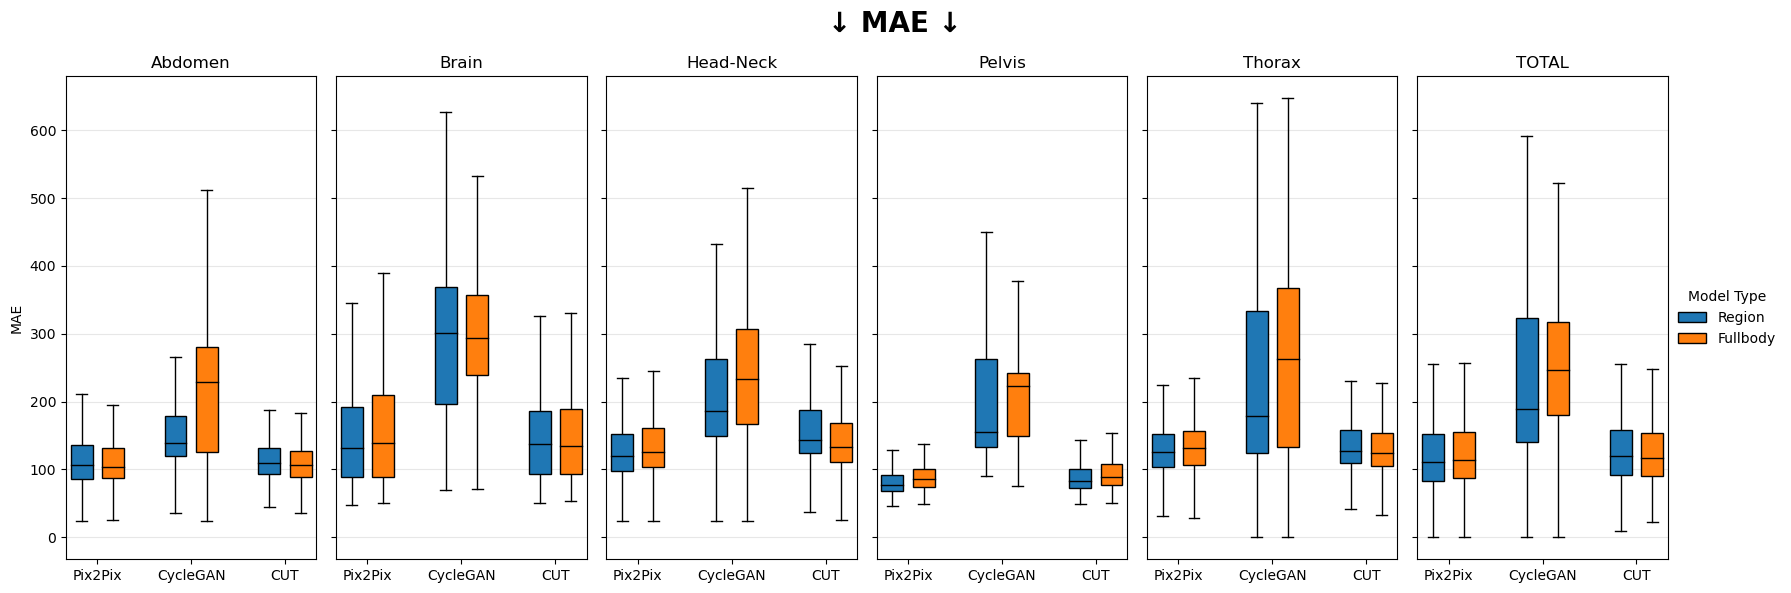

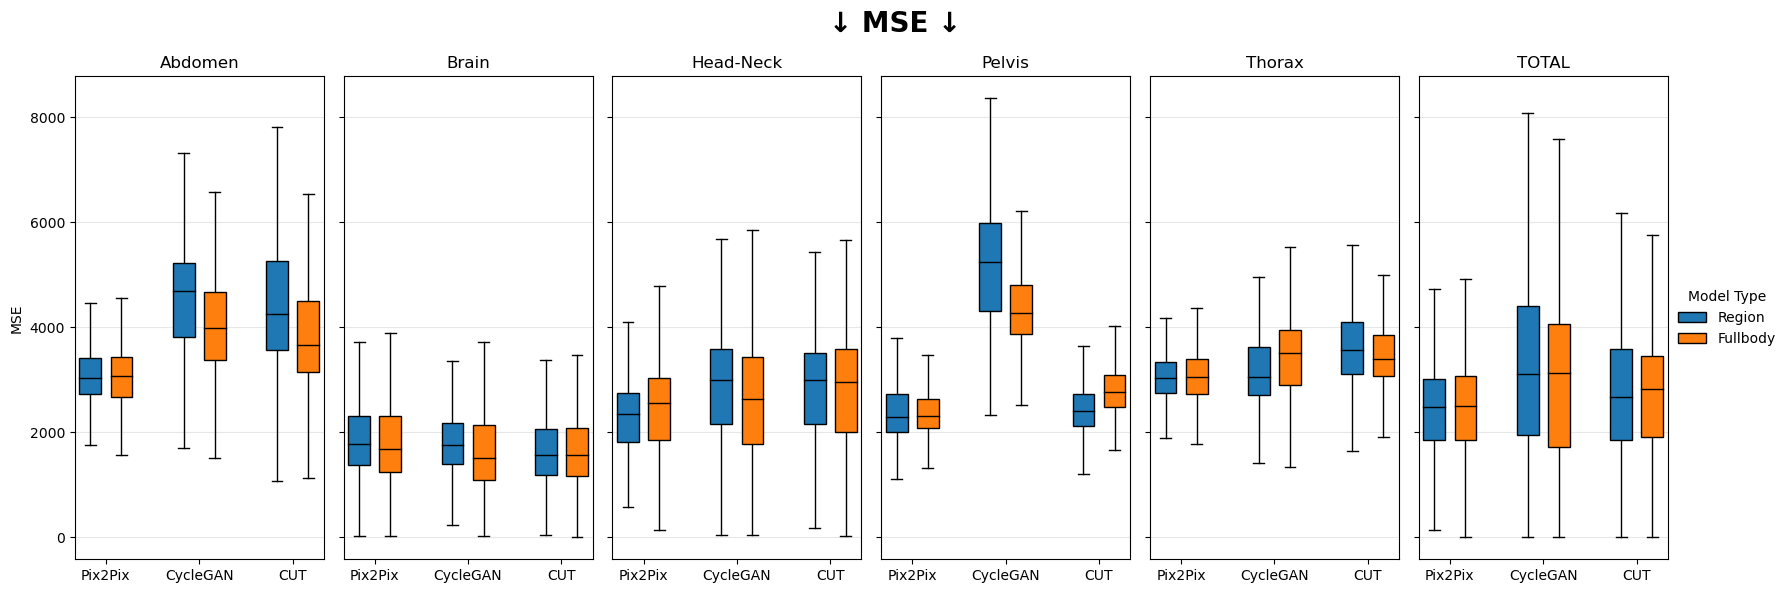

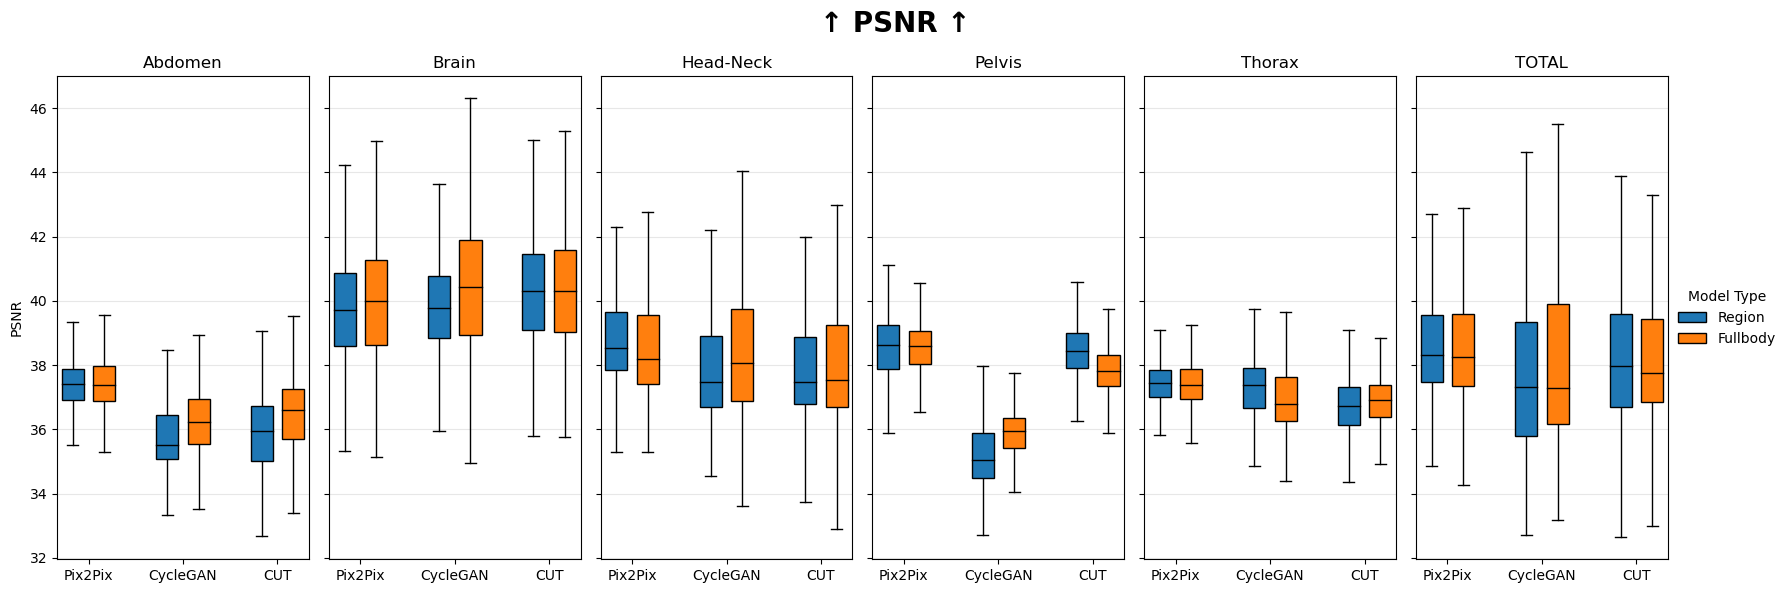

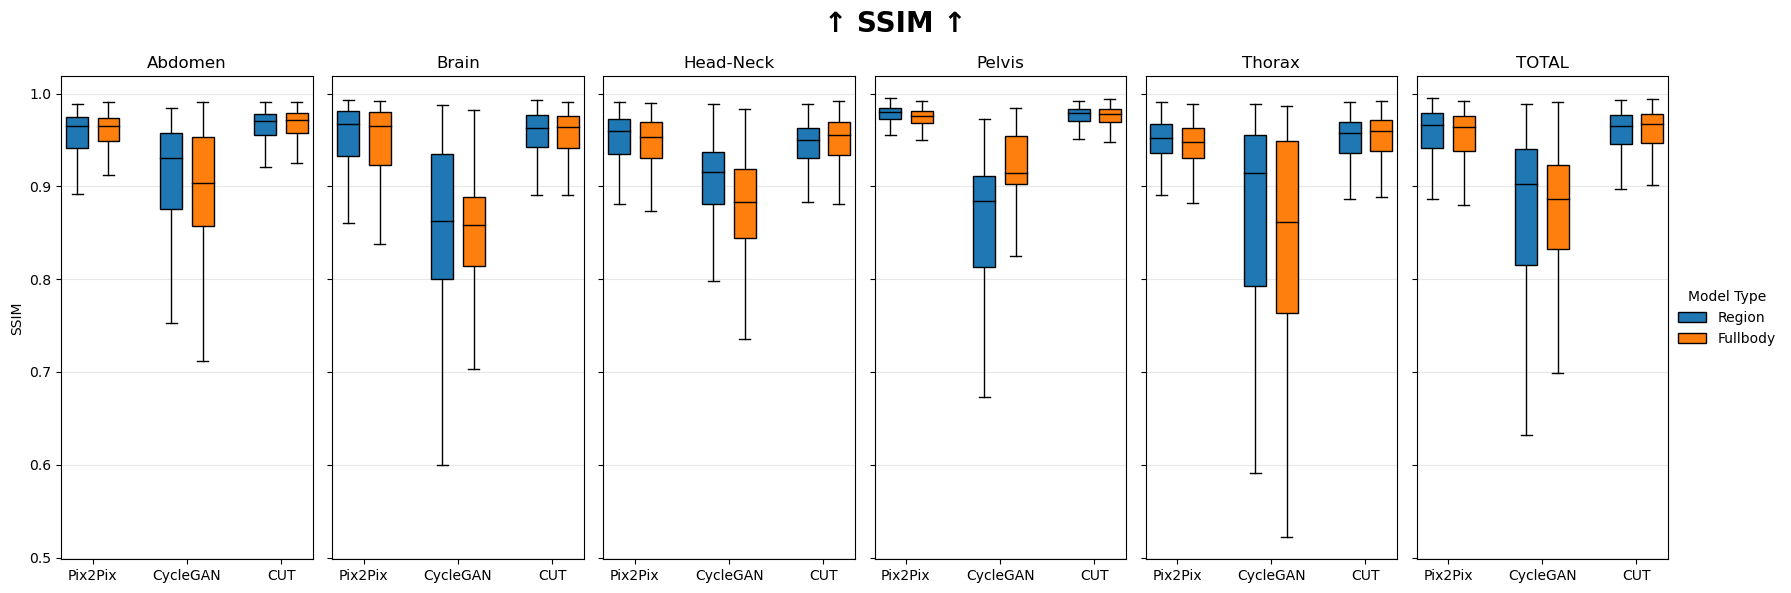

In [2]:
# Data loading
data_info_ex1 = pd.DataFrame(
    [
        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_brain_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_headneck_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_pelvis_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "pix2pix_synthrad_thorax_final/test_50/test_metrics_over_all.csv"],
        ["Fullbody", "Baseline", "pix2pix_synthrad_allregion_final/test_50/test_metrics_over_all.csv"],

        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_brain_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_head_neck_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_pelvis_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cyclegan_thorax_final/test_50/test_metrics_over_all.csv"],
        ["Fullbody", "Baseline", "cyclegan_allregions_final/test_50/test_metrics_over_all.csv"],
        
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_brain_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_HN_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_pelvis_final/test_50/test_metrics_over_all.csv"],
        ["Region", "Baseline", "cut_synthrad_TH_final/test_50/test_metrics_over_all.csv"],
        ["Fullbody", "Baseline", "cut_synthrad_allregions_final/test_50/test_metrics_over_all.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex1)
for metric in ["MAE", "MSE", "PSNR", "SSIM"]:
    # plot_metric_with_subplots(
    #     all_data,
    #     metric=metric,
    #     subplot_column="bodyregion",
    #     groups=["model", "region_or_fullbody"],
    #     legend_title="Model Type",
    # )
    plot_metric_with_subplots_incl_total(
        all_data,
        metric=metric,
        subplot_column="bodyregion",
        groups=["model", "region_or_fullbody"],
        legend_title="Model Type",
    )

# # to produce separate plots by metric and bodyregion
# for metric in ["MAE", "MSE", "PSNR", "SSIM"]:
#     for bodyregion in all_data["bodyregion"].unique():
#         plot_grouped_boxplots(all_data, "bodyregion", bodyregion, metric=metric, groups=["model", "region_or_fullbody"], legend_title="Separate Plots")

# Experiment 2

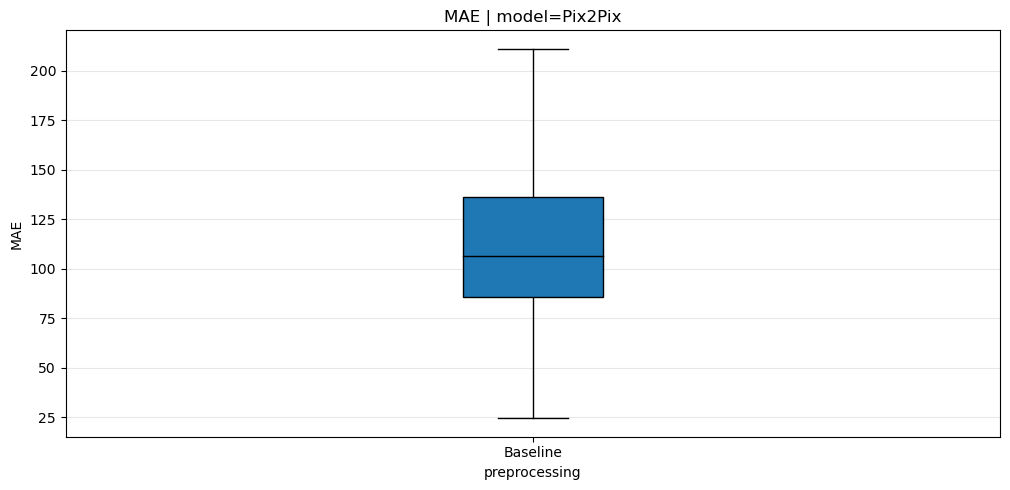

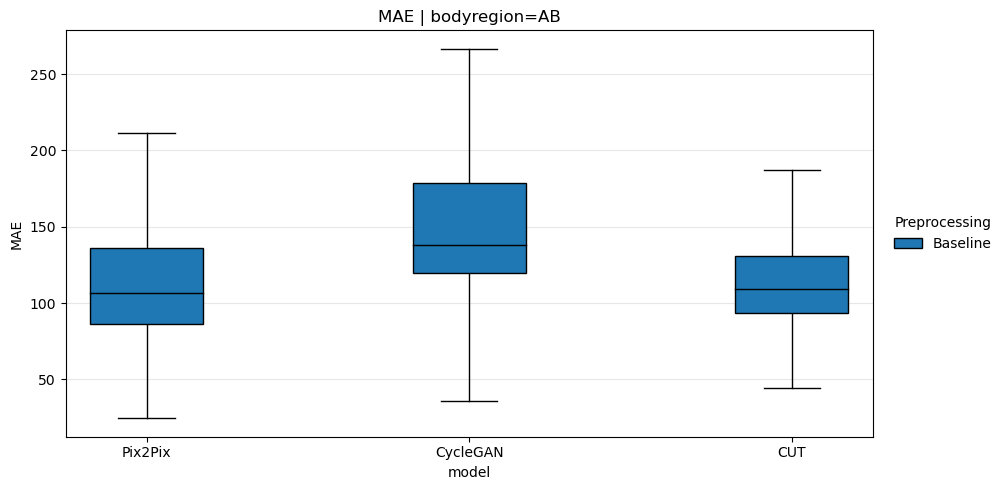

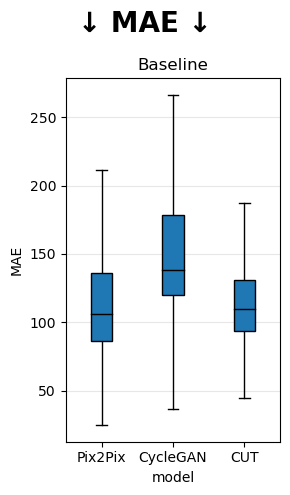

In [3]:
# Data loading
data_info_ex2 = pd.DataFrame(
    [
        ["Region", "Baseline", "pix2pix_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],

        ["Region", "Baseline", "cyclegan_abdomen_final/test_50/test_metrics_over_all.csv"],
        
        ["Region", "Baseline", "cut_synthrad_abdomen_final/test_50/test_metrics_over_all.csv"],
    ],
    columns=["region_or_fullbody", "preprocessing", "path"],
)

all_data = load_and_concat(data_info_ex2)
plot_grouped_boxplots(all_data, "model", "Pix2Pix", metric="MAE", groups=["preprocessing"])
plot_grouped_boxplots(all_data, "bodyregion", "AB", metric="MAE", groups=["model", "preprocessing"], legend_title="Preprocessing")


# not tested
plot_metric_with_subplots(
    all_data,
    metric="MAE",
    subplot_column="preprocessing",
    groups=["model"],
)